In [298]:
# Necessary Libraries
import numpy as np              # For numeric operations
import pandas as pd             # For data manipulation and analysis
import matplotlib.pyplot as plt # For data visualization
%matplotlib inline              

# To visualize text
from wordcloud import WordCloud

# For Naturla Language Processing
import nltk
from nltk.corpus import stopwords

# Downloading NLTK data
nltk.download('stopwords') # Downloading stopwords data
nltk.download('punkt')     # Downloading tokenizer data

[nltk_data] Downloading package stopwords to C:\Users\Gangotri
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Gangotri
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [299]:
# Read CSV file
df = pd.read_csv('spam.csv')

# Display the first few rows of DataFrame
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [300]:
# Removing unnecessary columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace= True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [301]:
# Columns name change
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace= True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Data Pre-processing

In [302]:
from sklearn.preprocessing import LabelEncoder

# Encoding text to numerical
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Check duplicate values
df.duplicated().sum()

# Drop duplicate
df = df.drop_duplicates(keep='first')
len(df)

5169

# Feature Engineering

In [304]:
# Importing the Porter stemmer for text Stemming
from nltk.stem.porter import PorterStemmer

# Importing the string module for handling special characters
import string

# Creating an instance of the Porter Stemmer
ps = PorterStemmer()

punkt
Ye actual tokenizer model hota hai
Pre-trained statistical model
Sentence & word boundaries samjhta hai

punkt_tab
Ye supporting data / lookup tables hain
Language-specific rules ka database
Tokenizer ko batata hai:
abbreviations (Mr., Dr.)
punctuation behavior
sentence ending rules

new tokenizer doesn't work without 'punkt_tab'

In [305]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

# Lowercase transformation and text preprocessing function
def transform_text(text):
    # Transform text to lowercase
    text = text.lower()
    
    # Tokenization using NLTK
    text = nltk.word_tokenize(text)
    
    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    # Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    # Join the processed tokens back into a single string
    return " ".join(y)

[nltk_data] Downloading package punkt to C:\Users\Gangotri
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Gangotri
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [306]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazi avail onli in bugi...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni ok lar ... joke wif u on...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,u dun say so earli hor u c alreadi then say u ...
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i do think he goe to usf he live around he...


🔹 1. CountVectorizer
👉 Kya karta hai?

Har word kitni baar aaya → count karta hai

Output = word frequency matrix


🔹 2. TF-IDF Vectorizer
👉 Kya karta hai?

TF (Term Frequency) → word kitni baar document me aaya

IDF (Inverse Document Frequency) → word kitne documents me aaya

👉 Rare words = higher weight
👉 Common words = lower weight

In [307]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Help us convert text to vector | very naive
cv = CountVectorizer(max_features=500)

# Help us convert text to vector | Advance
tv = TfidfVectorizer(max_features = 500)

🔹 scipy.sparse._csr.csr_matrix kya hai? why we have to convert tv.fit_transform(df['transformed_text']) to array

👉 Ye SciPy ka sparse matrix data structure hai
👉 Specifically CSR = Compressed Sparse Row matrix
Ye memory-efficient way hai badi matrices store karne ka jahan zyada values 0 hoti hain, it stores mainly non-zero value and their position.

now we have to convert it in array to use it

In [308]:
X = tv.fit_transform(df['transformed_text']).toarray()
Y = df['target'].values

# Train Test Split

In [309]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20, random_state = 2)

In [310]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [311]:
lrc = LogisticRegression(solver= 'liblinear', penalty= 'l1')
svc = SVC(kernel= "sigmoid", gamma= 1.0)
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth= 5)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators= 50, random_state= 2)
abc = AdaBoostClassifier(n_estimators= 50, random_state= 2)
bgc  = BaggingClassifier(n_estimators= 50, random_state= 2)
etc = ExtraTreesClassifier(n_estimators= 50, random_state= 2)
gbc = GradientBoostingClassifier(n_estimators= 50, random_state= 2)
xgb = XGBClassifier(n_estimator= 50, random_state= 2)

In [312]:
clfs = {
'lrc' : lrc,
'svc' : svc,
'mnb' : mnb,
'dtc' : dtc,
'knc' : knc,
'rfc' : rfc,
'abc' : abc,
'bgc' : bgc,
'etc' : etc,
'gbc' : gbc,
'xgb' : xgb
}

In [313]:
from sklearn.metrics import accuracy_score, precision_score

def train_classifier(clfs, x_train, x_test, y_train, y_test):
    clfs.fit(x_train, y_train)
    y_pred = clfs.predict(x_test)
    print(type(y_pred), type(y_test))
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [314]:
accuracy_list = []
precision_list = []
clfs_result = dict()
for name, clfs in clfs.items():
    acc, prec = train_classifier(clfs,  x_train, x_test, y_train, y_test)
    
    print("Classifier: ", name)
    print("Accuracy: ", acc)
    print("Precision: ", prec)

    accuracy_list.append(acc)
    precision_list.append(prec)

    clfs_result[name] = [acc, prec]

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  lrc
Accuracy:  0.971953578336557
Precision:  0.9504132231404959
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  svc
Accuracy:  0.971953578336557
Precision:  0.943089430894309
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  mnb
Accuracy:  0.9709864603481625
Precision:  0.9655172413793104
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  dtc
Accuracy:  0.941972920696325
Precision:  0.89
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  knc
Accuracy:  0.9294003868471954
Precision:  0.9850746268656716
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  rfc
Accuracy:  0.9748549323017408
Precision:  0.9827586206896551
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  abc
Accuracy:  0.9448742746615088
Precision:  0.9263157894736842
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  bgc
Accuracy:  0.965183752417795
Precision:  0.8805970149253731
<class 'num

c:\Users\Gangotri Mishra\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:08:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
Classifier:  xgb
Accuracy:  0.9796905222437138
Precision:  0.968


# Maximum accuracy from Dictionary of results

*max(clfs_result, key= lambda k: clfs_result[k][0])*

here we are giving **dicitionary** "clfs_result" as input and asking get the **max**
if **we dont give key**, then it will get the maxium key based on **alphabetic order of key**.
but if we are telling them to **utilize the 0th place value from each to compare** and then give us the maximum value Key

then it will **give us maximum key based on maximum 0th place value key**

# Ways to showing desired decimal values


In [315]:
best_classifier = max(clfs_result, key= lambda k: clfs_result[k][0])

print("Best Classifier: ", best_classifier)
print("Accuracy: ", f"{clfs_result[best_classifier][0]:.2f}")
print("Precision: ", f"{clfs_result[best_classifier][1]:.2f}")

# or 

print("Accuracy: ", round(clfs_result[best_classifier][0],2))
print("Precision: ", round(clfs_result[best_classifier][1],2))

Best Classifier:  xgb
Accuracy:  0.98
Precision:  0.97
Accuracy:  0.98
Precision:  0.97


In [316]:
train_classifier.__annotations__

{}

Q4. Wrap input conversion in try/except.
Task: Write a function to_int(x) that returns an int if possible; otherwise returns None without crashing.

In [ ]:
def to_int(x):
    try:
        return(int(x))
    except ():
        return None

Safe division with else and finally.
Task: Write safe_div(a, b) that:
Returns a / b
If division by zero → return float("inf")
Always prints "done" at the end (even if error)
Use else to print "ok" only when 

In [ ]:
def safe_div(a, b):
    try:
        result = a / b
    except ZeroDivisionError:
        return float("inf")
    else:
        print("ok")
        return result
    finally:
        print("done")

NameError: name 'o' is not defined

Scenario 3 — Missing Value Strategy with else for “Happy Path”
Goal: Apply different imputation strategies and acknowledge success only when none fails.
Task
Create impute_missing(df, rules) where rules is:
rules = {"age": "median", "income": "mean", "segment": "mode"}

Rules:
If a column is missing → raise KeyError.
If numeric strategy used on non-numeric column → raise TypeError.
Use else to log "imputation complete" only if all column operations succeed.
Always print "attempted imputation" in finally.

In [396]:
df = pd.DataFrame({"age": 24, "income": 45, "segment": "google"}, index= [0])

In [ ]:
rules = {"age": "median", "income": "mean", "segment": "mode"}
df = pd.DataFrame({{"age": 24, "income": 45, "segment": "google"}})
def impute_missing(df, rules):
    try:
        

Create class Person with attributes name & age.
Subclass Employee adds salary but should still call the Person initializer.

In [15]:
class person:
    def __init__(self, name, age):
        self.name = name
        self.age = age
class emp(person):
    def __init__(self, salary, name,age):
        super().__init__(name,age)
        self.salary = salary
        print(f"salary of {self.name} is {self.salary}")

e = emp(100,"ram",12)

Create a parent class Vehicle with method start().
Subclass Car should override start() to print "Car starts with a key".

In [18]:
class veh:
    def __init__(self):
        pass
    
    def start(self, nokey):
        self.nokey = nokey
        print(f"car start with {self.nokey}")

class car(veh):
    def __init__(self):
        pass

        # method overriding
    def start(self, start_meth):
        self.start_meth = start_meth
        print(f"car start method is {self.start_meth}")

c =car()
c.start("Big Key")

Question
Create a class BankAccount with a private balance (__balance).
Write methods to:
deposit money
get the current balance
Do NOT allow direct access to __balance.

In [24]:
class BankAccount:
    def __init__(self):
        self.__balance = 1000
        print("balance is: %s", self.__balance)
        
    
    def set_bal(self, bal):
        self.__balance = self.__balance + bal
        print("balance is: %s", self.__balance)
    
    def get_bal(self):
        return self.__balance

b = BankAccount()
b.set_bal(2000)
b.get_bal()

balance is: %s 1000
balance is: %s 3000


3000

In [2]:
a = (1,2,3)
b = (1,2,3)
a+b

(1, 2, 3, 1, 2, 3)

In [12]:
class CheckBinary:
	def __init__(self, s):
		self.s = s

	def check(self):
            x = str(self.s)
            check = 0
            for i in x:
                  print(i)
                  if i == '0' or i == '1':
                        check += 1
                  else:
                        check = -1
                        break
            if check >= 0:
                  return 'true'
            else:
                  return 'false'

In [13]:
a = CheckBinary(100110)

In [14]:
a.check()

1
0
0
1
1
0


'true'

In [5]:
import numpy as np
np.linspace(0,5,2)


array([0., 5.])

In [ ]:
np.full((4,5,3), np.arange(1,61))

ValueError: could not broadcast input array from shape (60,1) into shape (4,5,3)

In [13]:
class person:
    pass


p1 = person()
p2 = person()
print(p1==p2)

False


In [14]:
print(p1.__eq__(p2))

NotImplemented


In [27]:
class my:
    def __init__(self, value):
        self.value = value

    def __eq__(self, other):
        return self.value == other.value 
    
class oth(my):
    def __eq__(self, other):
        return self.value == other.value*2
    
a = my(10)
c = oth(5)
a == c ## why output False

5


False

In [38]:
import pandas as pd
train_data = pd.read_csv(r'E:\ML Ops\ML_Ops-ML_Pipeline\src\data\processed\train_tfidf.csv')

In [46]:
a = train_data.head()
a

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.404514,...,0.0,0.408638,0.0,0.0,0.406145,0.0,0.0,0.000000,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,1.000000,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.262704,0.000000,...,0.0,0.000000,0.0,0.0,0.214915,0.0,0.0,0.373621,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0


In [44]:
a.shape

(5, 101)

In [63]:
a.iloc[:,-1:].values.shape

(5, 1)

In [64]:
a.iloc[:,:-1].values.shape

(5, 100)

In [2]:
import os
print(os.path)

<module 'ntpath' (frozen)>


In [3]:
def add(a,b):
    return a-b

In [4]:
add(a,b)

NameError: name 'a' is not defined

In [1]:
import pandas as pd
import numpy as np
# Orders
orders = pd.DataFrame({
    'order_id': [101,102,103,104,105,106,107],
    'customer_id': [1,1,2,2,3,3,3],
    'product_id': [11,12,11,13,11,12,14],
    'quantity': [2,1,3,2,1,4,1],
    'price': [500, 1200, 500, 800, 500, 1200, 1500],
    'order_date': [
        '2024-01-05','2024-01-09','2024-02-14','2024-02-20','2024-03-01','2024-03-10','2024-03-11'
    ]
})
# Customers
customers = pd.DataFrame({
    'customer_id': [1,2,3,4],
    'city': ['Gurugram','Delhi','Noida','Gurugram'],
    'segment': ['Retail','SMB','Enterprise','Retail']
})
# Products
products = pd.DataFrame({
    'product_id': [11,12,13,14],
    'category': ['Beverages','Beverages','Snacks','Beverages'],
    'brand': ['ColdCo','ColdCo','SnackIt','ColdCo']
})
# Inventory / restocks (for concatenation)
restock_jan = pd.DataFrame({
    'product_id': [11,12,13],
    'qty_added': [100, 50, 20],
    'restock_date': ['2024-01-01','2024-01-15','2024-01-20']
})
restock_feb = pd.DataFrame({
    'product_id': [11,14],
    'qty_added': [80, 40],
    'restock_date': ['2024-02-05','2024-02-18']
})

In [2]:
orders.head()

,order_id,customer_id,product_id,quantity,price,order_date
0,101,1,11,2,500,2024-01-05
1,102,1,12,1,1200,2024-01-09
2,103,2,11,3,500,2024-02-14
3,104,2,13,2,800,2024-02-20
4,105,3,11,1,500,2024-03-01


In [3]:
orders.shape

(7, 6)

Q1. Create a new column revenue = quantity * price. Sort orders by revenue descending and keep only top 3.

In [35]:
orders['revenue']=orders['quantity']*orders['price']
orders.sort_values(by='revenue', ascending= True, inplace= True)
oo = orders.head(3)

Create a conditional flag: high_value_order if revenue >= 2000, else False.
Q4. Merge orders with customers on customer_id (inner join). How many rows?
Convert order_date to datetime and extract year, month, week, day_name.
Q17. Compute days_since_order relative to a reference date (e.g., 2024-03-15).
Write orders_full to CSV and read it back. Ensure dtypes are preserved (e.g., parse dates).
Q22. Downcast numeric columns to smaller dtypes; convert string categoricals to category.

In [36]:
oo['high_val_order'] = list(map(lambda x: 'high_value' if x >= 2000 else 'False', oo['revenue']))

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\2024975268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo['high_val_order'] = list(map(lambda x: 'high_value' if x >= 2000 else 'False', oo['revenue']))


In [37]:
merr = pd.merge(oo,customers, on = 'customer_id', how= 'inner')
merr.head()

,order_id,customer_id,product_id,quantity,price,order_date,revenue,high_val_order,city,segment
0,105,3,11,1,500,2024-03-01,500,False,Noida,Enterprise
1,101,1,11,2,500,2024-01-05,1000,False,Gurugram,Retail
2,102,1,12,1,1200,2024-01-09,1200,False,Gurugram,Retail


In [38]:
oo['datetime'] = pd.to_datetime(oo['order_date'])
oo['year'] = oo['datetime'].dt.year
oo['month'] = oo['datetime'].dt.month
oo['day'] = oo['datetime'].dt.day

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\978748380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo['datetime'] = pd.to_datetime(oo['order_date'])
C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\978748380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo['year'] = oo['datetime'].dt.year
C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\978748380.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

Compute days_since_order relative to a reference date (e.g., 2024-03-15).


In [39]:
oo['result_Day'] = (pd.to_datetime('2024-03-15') - oo['datetime']).dt.days

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\4175433108.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo['result_Day'] = (pd.to_datetime('2024-03-15') - oo['datetime']).dt.days


In [40]:
oo.to_csv('order.csv')
read_bk = pd.read_csv('order.csv')

Downcast numeric columns to smaller dtypes; convert string categoricals to category.
>>convert higer dtype like int64 ot int32 for numeric columns
>>catregorical columns have dtype of object but if we can convert in category it will be faster to access

In [41]:
oo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 4 to 1
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        3 non-null      int64         
 1   customer_id     3 non-null      int64         
 2   product_id      3 non-null      int64         
 3   quantity        3 non-null      int64         
 4   price           3 non-null      int64         
 5   order_date      3 non-null      object        
 6   revenue         3 non-null      int64         
 7   high_val_order  3 non-null      object        
 8   datetime        3 non-null      datetime64[ns]
 9   year            3 non-null      int32         
 10  month           3 non-null      int32         
 11  day             3 non-null      int32         
 12  result_Day      3 non-null      int64         
dtypes: datetime64[ns](1), int32(3), int64(7), object(2)
memory usage: 300.0+ bytes


In [42]:
oo.columns

Index(['order_id', 'customer_id', 'product_id', 'quantity', 'price',
       'order_date', 'revenue', 'high_val_order', 'datetime', 'year', 'month',
       'day', 'result_Day'],
      dtype='object')

In [43]:
oo.head()

,order_id,customer_id,product_id,quantity,price,order_date,revenue,high_val_order,datetime,year,month,day,result_Day
4,105,3,11,1,500,2024-03-01,500,False,2024-03-01,2024,3,1,14
0,101,1,11,2,500,2024-01-05,1000,False,2024-01-05,2024,1,5,70
1,102,1,12,1,1200,2024-01-09,1200,False,2024-01-09,2024,1,9,66


In [44]:
oo[['order_id', 'customer_id', 'product_id', 'quantity', 'price',
       'revenue','result_Day']] = oo[['order_id', 'customer_id', 'product_id', 'quantity', 'price',
       'revenue','result_Day']].astype('int32')
oo['high_val_order'] = oo['high_val_order'].astype('category')

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\3324046023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo[['order_id', 'customer_id', 'product_id', 'quantity', 'price',


In [46]:
oo['high_val_order'] = oo['high_val_order'].astype('category')

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_22692\1110530522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oo['high_val_order'] = oo['high_val_order'].astype('category')


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
np.random.seed(42)
# Synthetic dataset 1: Sales by Category over Months
months = pd.date_range('2024-01-01', periods=12, freq='MS').strftime('%b')
sales_df = pd.DataFrame({
    'Month': months,
    'Beverages': np.random.randint(80, 150, size=12),
    'Snacks': np.random.randint(50, 120, size=12),
    'Dairy': np.random.randint(60, 130, size=12),
})
# Synthetic dataset 2: Customer analytics (for scatter/pairplot/facet)
n = 300
customers_df = pd.DataFrame({
    'Age': np.random.normal(32, 8, n).clip(18, 60),
    'Income': np.random.normal(60000, 15000, n).clip(20000, 120000),
    'Spends': np.random.normal(1200, 400, n).clip(100, 3000),
    'City': np.random.choice(['Gurugram', 'Delhi', 'Noida'], size=n, p=[0.4, 0.35, 0.25]),
    'Segment': np.random.choice(['Retail', 'SMB', 'Enterprise'], size=n, p=[0.5, 0.3, 0.2]),
    'Gender': np.random.choice(['Male', 'Female'], size=n)
})
customers_df['Spend_perc_income'] = (customers_df['Spends'] * 12) / customers_df['Income']
# Synthetic dataset 3: Geo-like summary (country-level)
geo_df = pd.DataFrame({
    'country': ['India', 'United States', 'Brazil', 'Germany', 'Australia', 'South Africa'],
    'iso_alpha': ['IND', 'USA', 'BRA', 'DEU', 'AUS', 'ZAF'],
    'sales': [1200, 1500, 700, 800, 600, 500],
    'growth': [0.12, 0.08, 0.15, 0.05, 0.10, 0.06]
})

In [54]:
sales_df[['Beverages', 'Snacks', 'Dairy']].sum(axis=1)

0     365
1     309
2     331
3     292
4     324
5     276
6     261
7     350
8     238
9     298
10    279
11    269
dtype: int64

Q1. Basic Line Plot (Matplotlib)
Plot total monthly sales (sum across categories) as a line chart. Add markers, title, axis labels, and rotated x-ticks.

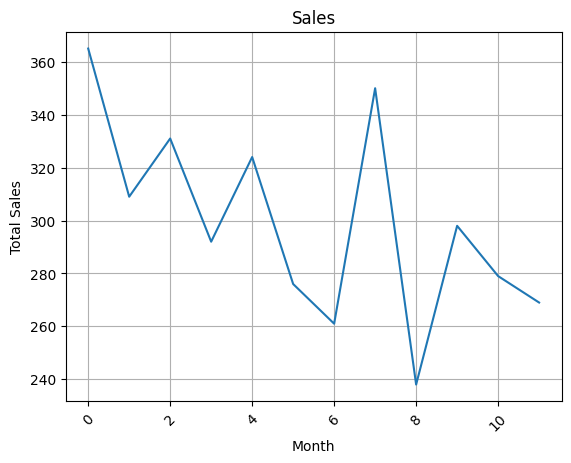

In [58]:
plt.plot(sales_df[['Beverages', 'Snacks', 'Dairy']].sum(axis=1))
plt.title('Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

Q2. Bar Chart (Seaborn)
Plot side-by-side bar chart of category-wise sales for March–June.

Q5. Boxplot (Seaborn)
Compare Spends across Segment.

Q6. Scatter Plot (Matplotlib)
Scatter Age vs Spends, color by City, size by Income.

In [59]:
class A(ABC):
    @abstractmethod
    def meth(self):
        pass
class B(A):
    def meth(self):
        print("B")
class C(A):
    def meth(self):
        print("inside C")



inside C
B


Abstract class are those classes where it inherits (ABC) abstract base class, along with-it abstract method is created using @abstractmethod decorators. Abstract class are used to define the methods and later they get inherited in different classes and get implemented accordingly


In [69]:
import numpy as np
aa = np.arange(10,51,2)

bb = np.eye(3)

In [66]:
import pandas as pd
data = {
    "Name": ["Amit", "Kavya", "Rohan", "Meera", "Arjun"],
    "Age": [25, 29, 35, 28, 40],
    "City": ["Delhi", "Mumbai", "Bangalore", "Delhi", "Chennai"],
    "Salary": [50000, 60000, 75000, 68000, 82000],
    "Department": ["IT", "HR", "Finance", "IT", "Finance"]
}
df = pd.DataFrame(data)

df.head()

,Name,Age,City,Salary,Department
0,Amit,25,Delhi,50000,IT
1,Kavya,29,Mumbai,60000,HR
2,Rohan,35,Bangalore,75000,Finance
3,Meera,28,Delhi,68000,IT
4,Arjun,40,Chennai,82000,Finance


In [67]:
df['Salary'].mean()
df[df['City'] == 'Delhi']['Name']
a = df.groupby('Department').mean('Salary')
df['salary_lakh'] = df['Salary'].map(lambda x : str(x/100000)) + ' Lakh'

np.float64(67000.0)

In [90]:
import seaborn as sns

In [ ]:
sns.boxplot(df , x = 'tip', y = 'day', hue = 'gender')


ValueError: Could not interpret value `tip` for `x`. An entry with this name does not appear in `data`.

In [1]:
class MyClass:
    def __init__(self, n):
        self.n = n
        self.current = 0

    def __iter__(self):
        print("iter called")
        return self

    def __next__(self):
        print("next called")
        if self.current < self.n:
            self.current += 1
            return self.current
        else:
            raise StopIteration

In [3]:
obj = MyClass(3)

for x in obj:
    print("dfdfdd")
    print(x)

iter called
next called
dfdfdd
1
next called
dfdfdd
2
next called
dfdfdd
3
next called


In [6]:
import numpy as np

A = np.random.rand(2,3)
B = np.random.rand(3,4)

np.einsum('ij,jk->ik', A, B)


array([[0.75684999, 0.34117462, 1.05662615, 0.41445787],
       [0.22453065, 0.13745216, 0.39301562, 0.11553178]])

In [7]:
import numpy as np

arr1 = np.arange(0,10)
print(arr1)

arr2 = np.arange(0,12).reshape(4,3)
arr2 = arr2.reshape(3,4)
print(arr2)

arr3 = np.zeros((1000,1000))
print(arr3.itemsize)


8

In [10]:

arr4 = np.linspace(0,1,10)
print(arr4)

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [22]:
arr5  = np.random.randint(1,10,size = (5,5))
print(arr5[[1],[2]])
print(arr5[:2])

array([[8, 2, 7, 8, 5],
       [2, 7, 9, 7, 3],
       [9, 4, 7, 9, 6],
       [8, 4, 7, 1, 2],
       [5, 2, 9, 2, 8]], dtype=int32)

In [23]:
arr6  = np.random.randint(1,10,size = (5,5))
arr6[arr6 >5]

array([[2, 2, 2, 7, 1],
       [9, 9, 5, 2, 6],
       [5, 6, 7, 6, 4],
       [9, 1, 7, 4, 4],
       [1, 4, 3, 7, 3]], dtype=int32)

In [ ]:
arr71  = np.random.randint(1,10,size = (3,3))
arr72  = np.random.randint(1,10,size = (3,3))

print(arr71+arr72)
print(arr71-arr72)
print(arr71*arr72)
print(arr71/arr72)

In [33]:
np.random.random(0,1)

TypeError: random() takes at most 1 positional argument (2 given)

In [41]:
arr91  = np.arange(0,3)
arr92  = np.arange(3,6)
print(arr91 + arr92)
print(arr91 - arr92)
print(np.dot(arr92,arr91))
print(np.cross(arr91,arr92))

[0 1 2]
[3 4 5]


In [54]:
arr10  = np.arange(0,3)
print(arr10 + 2)
print(arr10.T)

arr102 = np.random.normal(loc=0, scale=1, size=(3, 3))
print(arr102)

[2 3 4]
[0 1 2]
[[ 0.58760876 -0.65613136  0.50897626]
 [ 0.234739   -1.23949582  0.33983287]
 [ 0.44995269  0.00994758  0.28741691]]


In [53]:
arr10.T

array([0, 1, 2])

In [55]:
import pandas as pd
# Sample sales data for a month
data = {
    'Sales': [1200, 1500, 1800, 2000, 2500, 3000, 2800, 2200, 2300, 2700, 3200, 2900]
}
df = pd.DataFrame(data)

In [61]:
df.describe()

,Sales
count,12.000000
mean,2341.666667
std,624.439142
min,1200.000000
25%,1950.000000
50%,2400.000000
75%,2825.000000
max,3200.000000


In [68]:
df['Sales'].sort_values().median()

np.float64(2400.0)

In [69]:
import numpy as np
import pandas as pd
# Sample blood pressure readings (systolic, diastolic)
data = {
    'Systolic': [120, 130, 125, 140, 135, 145, 150, 140, 135, 130],
    'Diastolic': [80, 85, 82, 90, 88, 92, 95, 88, 86, 84]
}
df = pd.DataFrame(data)

In [71]:
df.describe()

,Systolic,Diastolic
count,10.000000,10.000000
mean,135.000000,87.000000
std,9.128709,4.570436
min,120.000000,80.000000
25%,130.000000,84.250000
50%,135.000000,87.000000
75%,140.000000,89.500000
max,150.000000,95.000000


In [73]:
df['Diastolic'].median()

np.float64(87.0)

In [74]:
df['Systolic'].median()

np.float64(135.0)

In [79]:
df

,Systolic,Diastolic
0,120,80
1,130,85
2,125,82
3,140,90
4,135,88
5,145,92
6,150,95
7,140,88
8,135,86
9,130,84


In [84]:
df.iloc[0,1]

np.int64(80)

In [86]:
df.iloc[0][0]

C:\Users\Gangotri Mishra\AppData\Local\Temp\ipykernel_26884\2900375399.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][0]


np.int64(120)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Systolic   10 non-null     int64
 1   Diastolic  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [3]:
import pandas as pd
import numpy as np

In [4]:
df1=pd.DataFrame({
      'A' : [10, 20, 30, 40, 50],
      'B':  [1, 2, 3, 4, 5],
      'C': [6, 7, 8, 9, 10]
})

In [5]:
df2=pd.DataFrame({
      'A' : [10, 20, 30, 40, 50],
      'B':  [1, 2, 3, 4, 5],
      'C': [6, 7, 8, 9, 10]
})

In [8]:
pd.concat([df1,df2], axis= 1)

,A,B,C,A,B,C
0,10,1,6,10,1,6
1,20,2,7,20,2,7
2,30,3,8,30,3,8
3,40,4,9,40,4,9
4,50,5,10,50,5,10


In [9]:
df1

,A,B,C
0,10,1,6
1,20,2,7
2,30,3,8
3,40,4,9
4,50,5,10


In [11]:
df1['A'] = [10,20,20,30,30]

How would you group a DataFrame df by column 'A' and compute the mean of column 'B' for each group? Provide three different Pandas methods to achieve this.

In [ ]:
df1.groupby(['A']).mean()
df1.groupby(['A']).agg({'B':'mean'})
pd.pivot_table(df1, index= 'A', values='B', aggfunc= 'mean')

,B,C
A,,
10,1.0,6.0
20,2.5,7.5
30,4.5,9.5


In [19]:
dd = pd.date_range('2024-01-01','2024-01-10')

In [25]:
val = np.arange(0,10)

In [26]:
val

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [27]:
dict = {'dat':dd,'val':val}

In [28]:
dict

{'dat': DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
                '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
                '2024-01-09', '2024-01-10'],
               dtype='datetime64[ns]', freq='D'),
 'val': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])}

In [30]:
df2 = pd.DataFrame(dict)

In [31]:
df2['dat'].dt.month

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: dat, dtype: int32

In [34]:
df1+10

,A,B,C
0,20,11,16
1,30,12,17
2,30,13,18
3,40,14,19
4,40,15,20


<Axes: xlabel='A'>

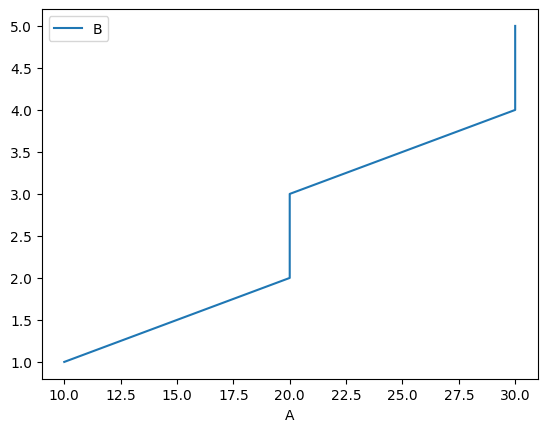

In [35]:
df1.plot('A','B')

## Probability Distribution
The number of emails a person receives per hour follows which distribution?
- Poission

You are calling customers until you make 3 sales. What distribution models the total number of calls required?
- Negative

A student keeps taking a test until they pass. What distribution models the number of attempts?
- Geometric

A call center receives an average of 5 calls per hour. What distribution models the number of calls in an hour?
- Poisson

The errors in a measuring instrument (like a scale or thermometer) gently fluctuate around zero, with small errors more common than large ones.
- Gaussian

IQ scores of a population tend to cluster around the average IQ of 100, with fewer people having extremely high or low IQ.
- Gaussian

You’re monitoring how long it takes for the next email to arrive in your inbox.
Distribution?
- Exponential

You want to update your belief about a cricket player’s true batting average after observing a few matches.
Distribution?
- Beta Distribution

The failure of a machine part requires multiple stress cycles, not just one. You want to model the total time until failure.
Distribution?
- Exponential

A hospital tracks how long it takes for 5 patients to arrive in the emergency room.
Which distribution fits the total waiting time?
- Gamma

You are checking whether observed frequencies (e.g., male vs female buying a product) match expected frequencies.
Which distribution is used for the test statistic?
- Chi-square